# Customer Segmentation & RFM Analysis

RFM (Recency, Frequency, Monetary) analysis on transaction data, followed by K-Means clustering to group customers into segments and a recency-based churn risk flag. Segment and churn summary tables are exported at the end for use in Power BI.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("rfm_sales.csv")
df.sample(7)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
177805,578858,22023,EMPIRE BIRTHDAY CARD,12,2011-11-27 11:22:00.0000000,0.42,18145,United Kingdom,5.040000
313158,544657,85014B,RED RETROSPOT UMBRELLA,3,2011-02-22 13:08:00.0000000,5.95,14895,United Kingdom,17.849999
51788,560449,22990,COTTON APRON PANTRY DESIGN,2,2011-07-19 09:31:00.0000000,4.95,14732,United Kingdom,9.900000
327407,548708,22860,EASTER TIN CHICKS PINK DAISY,1,2011-04-03 12:41:00.0000000,1.65,13269,United Kingdom,1.650000
152940,572294,21485,RETROSPOT HEART HOT WATER BOTTLE,2,2011-10-23 13:10:00.0000000,4.95,13471,United Kingdom,9.900000
150156,569897,85015,SET OF 12 VINTAGE POSTCARD SET,2,2011-10-06 16:01:00.0000000,0.65,17813,United Kingdom,1.300000
137572,574675,22211,WOOD STAMP SET FLOWERS,1,2011-11-06 12:31:00.0000000,0.83,17289,United Kingdom,0.830000


In [3]:
df.shape

(392692, 9)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  str           
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), str(3)
memory usage: 27.0 MB


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

## 3. Data Cleaning Checks

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.799999
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.593821
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099214


In [9]:
df['CustomerID'].nunique()

4338

In [10]:
df['InvoiceNo'].nunique()

18532

In [11]:
df['TotalAmount'].sum()

np.float64(8887208.837974273)

## 4. RFM Metric Calculation

In [13]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [14]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

In [15]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.597169
1,12347,2,7,4309.999988
2,12348,75,4,1797.239997
3,12349,19,1,1757.549994
4,12350,310,1,334.399997


In [16]:
rfm.shape

(4338, 4)

In [17]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688068
std,1721.808492,100.014169,7.697998,8985.230163
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482502
50%,15299.500000,51.000000,2.000000,668.569998
75%,16778.750000,142.000000,5.000000,1660.597490
max,18287.000000,374.000000,209.000000,280206.019436


### 4.1 RFM Scores (1-5)

In [18]:
# Create RFM scores (1-5)

rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [19]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [20]:
rfm['RFM_Total'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

In [21]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.597169,1,1,5,115,7
1,12347,2,7,4309.999988,5,5,5,555,15
2,12348,75,4,1797.239997,2,4,4,244,10
3,12349,19,1,1757.549994,4,1,4,414,9
4,12350,310,1,334.399997,1,1,2,112,4
5,12352,36,8,2506.039979,3,5,5,355,13
6,12353,204,1,89.000000,1,1,1,111,3
7,12354,232,1,1079.400008,1,1,4,114,6
8,12355,214,1,459.399999,1,1,2,112,4
9,12356,23,3,2811.429985,4,3,5,435,12


In [22]:
rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Total']].describe()

,R_Score,F_Score,M_Score,RFM_Total
count,4338.00000,4338.00000,4338.00000,4338.000000
mean,3.00000,3.00000,3.00000,9.000000
std,1.41454,1.41454,1.41454,3.589625
min,1.00000,1.00000,1.00000,3.000000
25%,2.00000,2.00000,2.00000,6.000000
50%,3.00000,3.00000,3.00000,9.000000
75%,4.00000,4.00000,4.00000,12.000000
max,5.00000,5.00000,5.00000,15.000000


## 5. Exploratory Data Analysis


### 5.1 Distribution Check

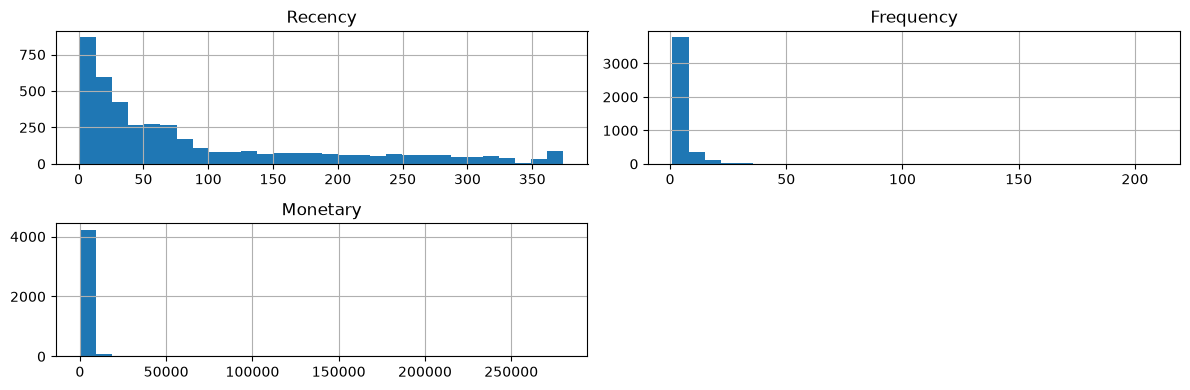

In [23]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

In [24]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

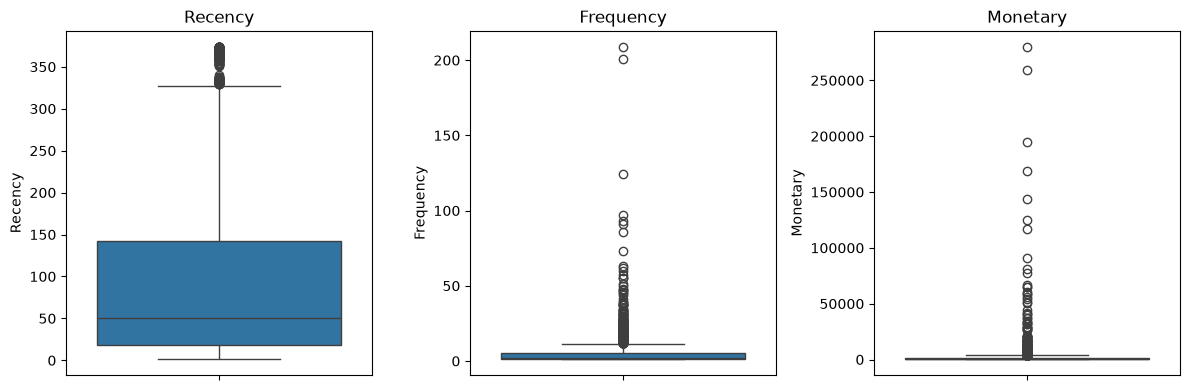

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm['Recency'])
plt.title('Recency')

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm['Frequency'])
plt.title('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary')

plt.tight_layout()
plt.show()

### 5.2 Log Transformation

In [26]:
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

In [27]:
rfm[['Recency_log', 'Frequency_log', 'Monetary_log']].skew()

Recency_log     -0.379169
Frequency_log    1.208652
Monetary_log     0.396599
dtype: float64

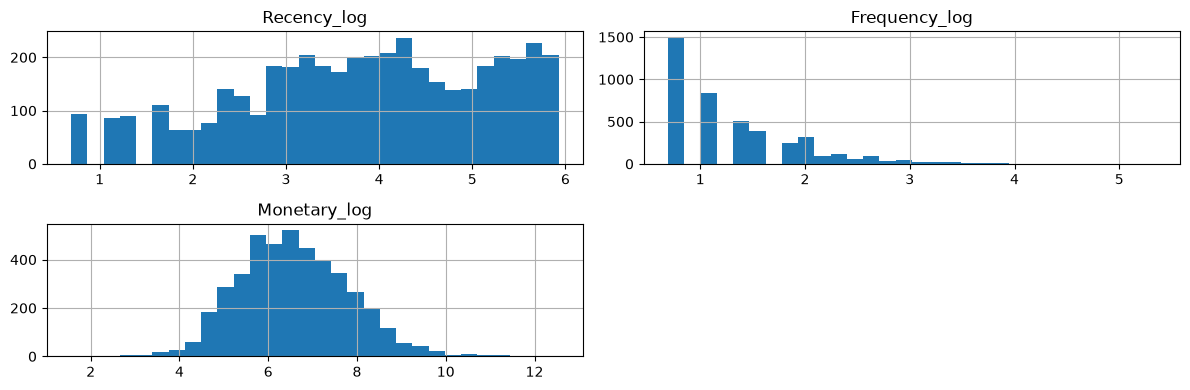

In [28]:
rfm[['Recency_log', 'Frequency_log', 'Monetary_log']].hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

### 5.3 Feature Scaling

In [29]:
rfm_features = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [30]:
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.70771628],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

In [31]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.096576e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-3.997811e+00
25%,-6.613615e-01,-9.552143e-01,-6.835802e-01
50%,8.992557e-02,-3.615828e-01,-6.510929e-02
75%,8.447915e-01,6.532370e-01,6.572178e-01
max,1.564198e+00,5.858535e+00,4.732381e+00


## 6. K-Means Clustering - Model Selection

### 6.1 Elbow & Silhouette Evaluation


In [32]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

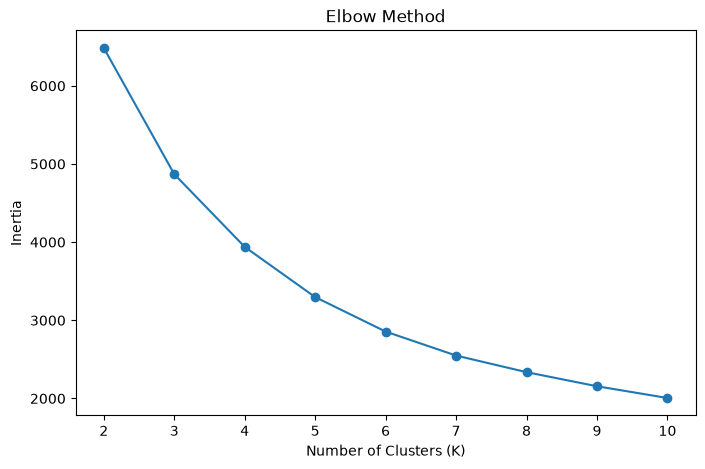

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

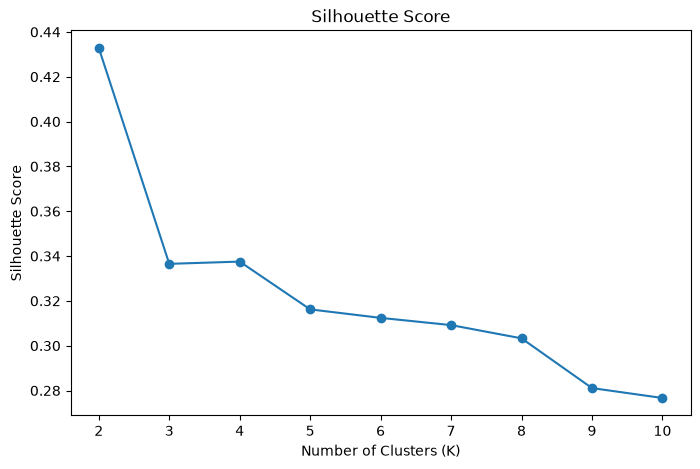

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()

In [35]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.3f}")

K=2: Silhouette Score=0.433
K=3: Silhouette Score=0.337
K=4: Silhouette Score=0.338
K=5: Silhouette Score=0.316
K=6: Silhouette Score=0.312
K=7: Silhouette Score=0.309
K=8: Silhouette Score=0.303
K=9: Silhouette Score=0.281
K=10: Silhouette Score=0.277


### 6.2 Compare Candidate Cluster Solutions


In [36]:
cluster_comparison = []

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    cluster_comparison.append({
        'K': k,
        'Inertia': kmeans.inertia_,
        'Silhouette': silhouette_score(rfm_scaled, labels)
    })

pd.DataFrame(cluster_comparison)

,K,Inertia,Silhouette
0,2,6483.589426,0.432827
1,3,4869.488630,0.336517
2,4,3939.049382,0.337517


In [37]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    print(f"\nK = {k}")
    print(pd.Series(labels).value_counts().sort_index())


K = 2
0    2672
1    1666
Name: count, dtype: int64

K = 3
0     769
1    1872
2    1697
Name: count, dtype: int64

K = 4
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


## 7. Final K-Means Model


### 7.1 Cluster Profile

In [38]:
# Final K-Means Model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Recency_log,Frequency_log,Monetary_log,Cluster
0,12346,326,1,77183.597169,1,1,5,115,7,5.789960,0.693147,11.253955,3
1,12347,2,7,4309.999988,5,5,5,555,15,1.098612,2.079442,8.368925,0
2,12348,75,4,1797.239997,2,4,4,244,10,4.330733,1.609438,7.494564,3
3,12349,19,1,1757.549994,4,1,4,414,9,2.995732,0.693147,7.472245,2
4,12350,310,1,334.399997,1,1,2,112,4,5.739793,0.693147,5.815324,1
5,12352,36,8,2506.039979,3,5,5,355,13,3.610918,2.197225,7.826858,3
6,12353,204,1,89.000000,1,1,1,111,3,5.323010,0.693147,4.499810,1
7,12354,232,1,1079.400008,1,1,4,114,6,5.451038,0.693147,6.985087,1
8,12355,214,1,459.399999,1,1,2,112,4,5.370638,0.693147,6.132096,1
9,12356,23,3,2811.429985,4,3,5,435,12,3.178054,1.386294,7.941804,3


In [39]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [40]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [41]:
cluster_profile['Customer_Count'] = rfm.groupby('Cluster').size()

cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,12.17,13.75,8088.02,713
1,181.51,1.32,341.00,1622
2,17.70,2.19,557.32,837
3,71.64,4.08,1801.78,1166


### 7.2 Cluster Comparison


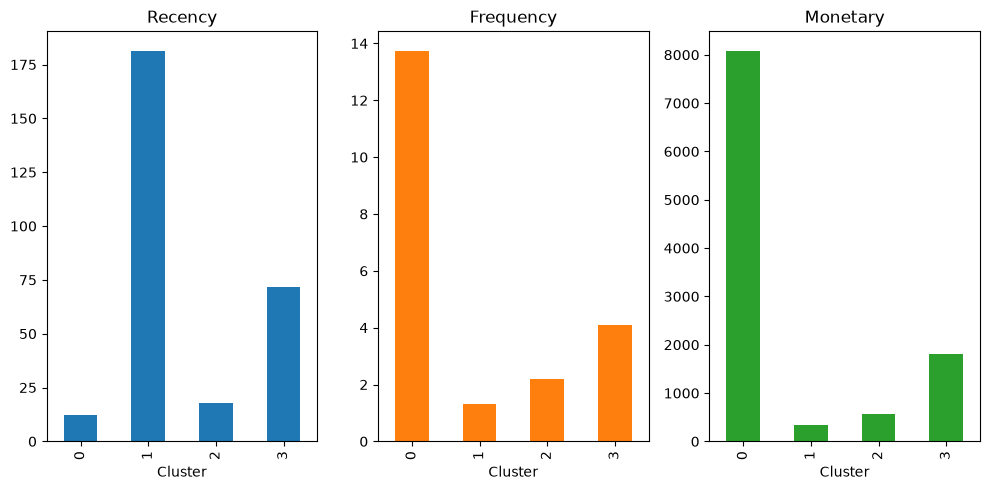

In [42]:
cluster_profile[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar',
    figsize=(10, 5),
    subplots=True,
    layout=(1, 3),
    legend=False
)

plt.tight_layout()
plt.show()

## 8. Business-Friendly Customer Segmentation


In [46]:
# Assign business-friendly segment names

segment_map = {
    0: 'Champions',
    1: 'Lost Customers',
    2: 'Potential Loyalists',
    3: 'Need Attention'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm[['CustomerID', 'Cluster', 'Segment']].head(10)

,CustomerID,Cluster,Segment
0,12346,3,Need Attention
1,12347,0,Champions
2,12348,3,Need Attention
3,12349,2,Potential Loyalists
4,12350,1,Lost Customers
5,12352,3,Need Attention
6,12353,1,Lost Customers
7,12354,1,Lost Customers
8,12355,1,Lost Customers
9,12356,3,Need Attention


In [47]:
rfm['Segment'].value_counts()

Segment
Lost Customers         1622
Need Attention         1166
Potential Loyalists     837
Champions               713
Name: count, dtype: int64

## 9. Churn Risk Classification


In [49]:
# Assign churn risk based on customer recency

def churn_risk(recency):
    if recency > 180:
        return 'High'
    elif recency > 90:
        return 'Medium'
    else:
        return 'Low'

rfm['Churn_Risk'] = rfm['Recency'].apply(churn_risk)

rfm[['CustomerID', 'Recency', 'Segment', 'Churn_Risk']].head(10)

,CustomerID,Recency,Segment,Churn_Risk
0,12346,326,Need Attention,High
1,12347,2,Champions,Low
2,12348,75,Need Attention,Low
3,12349,19,Potential Loyalists,Low
4,12350,310,Lost Customers,High
5,12352,36,Need Attention,Low
6,12353,204,Lost Customers,High
7,12354,232,Lost Customers,High
8,12355,214,Lost Customers,High
9,12356,23,Need Attention,Low


In [50]:
rfm['Churn_Risk'].value_counts()

Churn_Risk
Low       2889
High       860
Medium     589
Name: count, dtype: int64

## 10. Final Dataset for Export

In [52]:
# Create final customer-level dataset for Power BI

final_rfm = rfm[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'R_Score',
        'F_Score',
        'M_Score',
        'RFM_Total',
        'Segment',
        'Churn_Risk'
    ]
].copy()

final_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment,Churn_Risk
0,12346,326,1,77183.597169,1,1,5,7,Need Attention,High
1,12347,2,7,4309.999988,5,5,5,15,Champions,Low
2,12348,75,4,1797.239997,2,4,4,10,Need Attention,Low
3,12349,19,1,1757.549994,4,1,4,9,Potential Loyalists,Low
4,12350,310,1,334.399997,1,1,2,4,Lost Customers,High


In [53]:
final_rfm.shape

(4338, 10)

In [54]:
final_rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
R_Score       0
F_Score       0
M_Score       0
RFM_Total     0
Segment       0
Churn_Risk    0
dtype: int64

In [55]:
# Export final RFM dataset for Power BI

final_rfm.to_csv('final_rfm_customer_segmentation.csv', index=False)

print("File exported successfully!")
print("Rows:", final_rfm.shape[0])
print("Columns:", final_rfm.shape[1])

File exported successfully!
Rows: 4338
Columns: 10


## 11. Summary Tables for Power BI

### 11.1 Segment Summary


In [57]:
# Segment summary for Power BI

segment_summary = (
    final_rfm
    .groupby('Segment')
    .agg(
        Customer_Count=('CustomerID', 'count'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_summary['Customer_Percentage'] = (
    segment_summary['Customer_Count']
    / segment_summary['Customer_Count'].sum() * 100
).round(2)

segment_summary

,Segment,Customer_Count,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
0,Champions,713,5.766757e+06,12.171108,13.751753,8088.018280,16.44
1,Lost Customers,1622,5.530998e+05,181.506782,1.316893,340.998624,37.39
2,Need Attention,1166,2.100873e+06,71.635506,4.078902,1801.777881,26.88
3,Potential Loyalists,837,4.664790e+05,17.698925,2.192354,557.322613,19.29


In [58]:
segment_summary.to_csv('segment_summary.csv', index=False)

print("Segment summary exported successfully!")

Segment summary exported successfully!


### 11.2 Churn Summary


In [59]:
churn_summary = (
    final_rfm
    .groupby('Churn_Risk')
    .agg(
        Customer_Count=('CustomerID', 'count'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

churn_summary['Customer_Percentage'] = (
    churn_summary['Customer_Count']
    / churn_summary['Customer_Count'].sum() * 100
).round(2)

churn_summary

,Churn_Risk,Customer_Count,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
0,High,860,5.548330e+05,269.118605,1.504651,645.154611,19.82
1,Low,2889,7.854667e+06,31.813084,5.484251,2718.818468,66.60
2,Medium,589,4.777093e+05,132.551783,2.366723,811.051473,13.58


In [60]:
churn_summary.to_csv('churn_summary.csv', index=False)

print("Churn summary exported successfully!")

Churn summary exported successfully!
